In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("/content/household_power_consumption.csv")

In [ ]:
# Combine Date + Time
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('datetime', inplace=True)

# Keep only needed column
df = df[['Global_active_power']]

# Convert to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Remove invalid values
df = df.replace([np.inf, -np.inf], np.nan)

In [ ]:
df = df.resample('D').mean()
df = df.fillna(method='ffill')

/tmp/ipykernel_2691/2934721383.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
df.head()

,Global_active_power
datetime,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


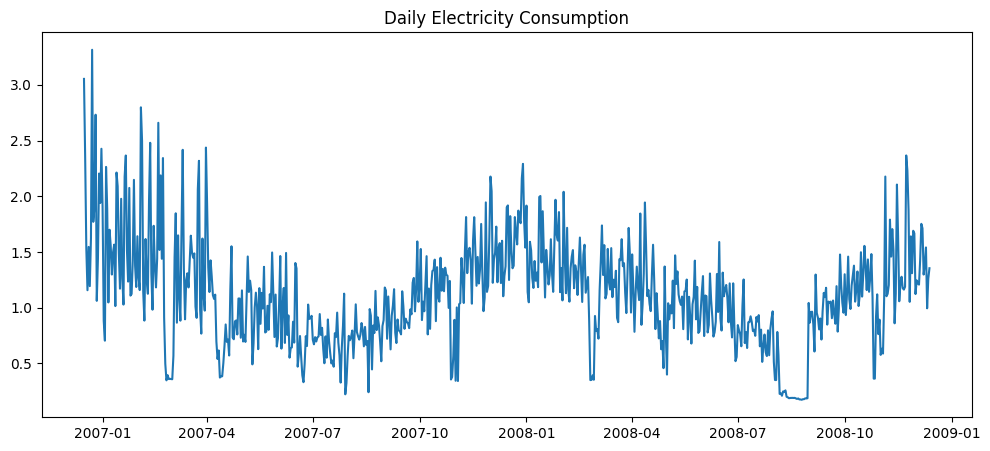

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Global_active_power'])
plt.title("Daily Electricity Consumption")
plt.show()

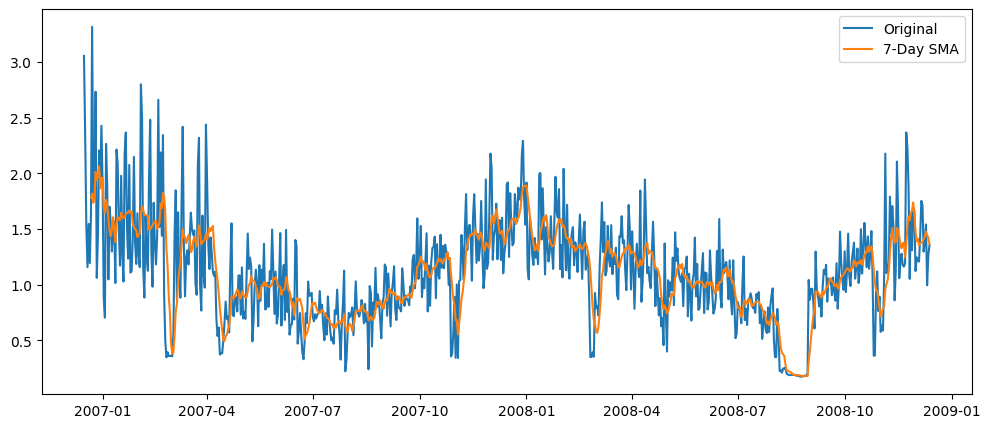

In [ ]:
df['SMA_7'] = df['Global_active_power'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Global_active_power'], label='Original')
plt.plot(df['SMA_7'], label='7-Day SMA')
plt.legend()
plt.show()

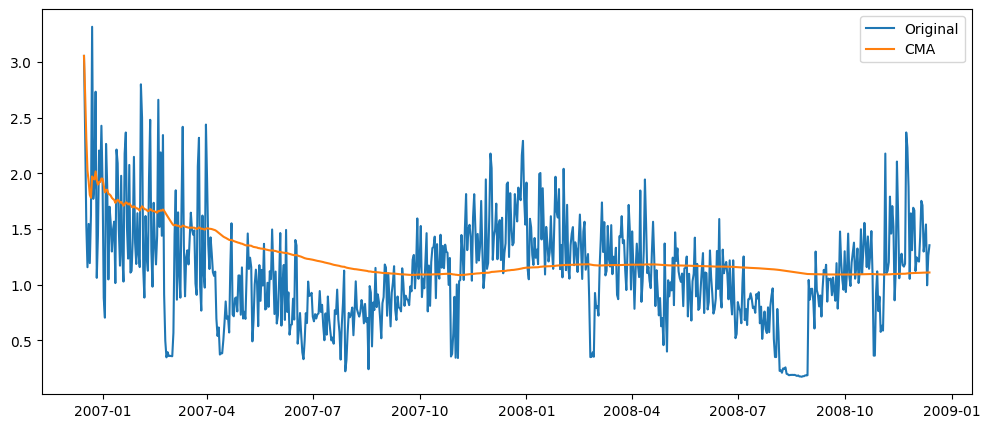

In [ ]:
df['CMA'] = df['Global_active_power'].expanding().mean()

plt.figure(figsize=(12,5))
plt.plot(df['Global_active_power'], label='Original')
plt.plot(df['CMA'], label='CMA')
plt.legend()
plt.show()

In [ ]:
df.head(20)

,Global_active_power,SMA_7,CMA
datetime,,,
2006-12-16,3.053475,NaN,3.053475
2006-12-17,2.354486,NaN,2.703980
2006-12-18,1.530435,NaN,2.312799
2006-12-19,1.157079,NaN,2.023869
2006-12-20,1.545658,NaN,1.928227
2006-12-21,1.193758,NaN,1.805815
2006-12-22,1.625929,1.780117,1.780117
2006-12-23,3.314851,1.817457,1.971959
2006-12-24,1.770842,1.734079,1.949613


Staitionarity


In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    series = series.dropna()
    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print(" Data is Stationary")
    else:
        print(" Data is NOT Stationary")

adf_test(df['Global_active_power'])

ADF Statistic: -2.7525232250102607
p-value: 0.06538201867803144
 Data is NOT Stationary


Its a non stationary data as p value greater than 0.05

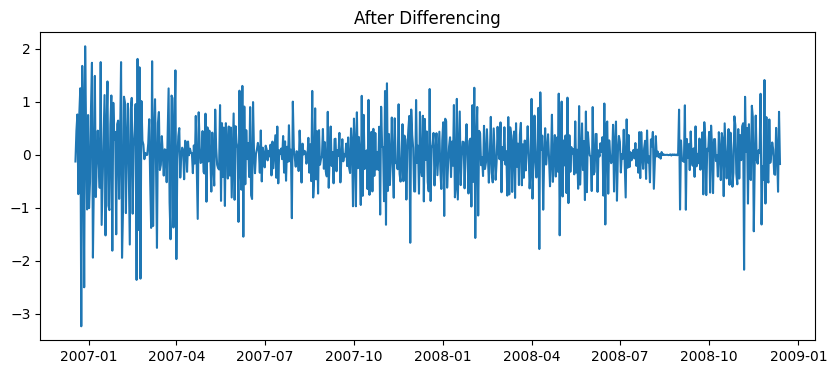

ADF Statistic: -12.693046771689536
p-value: 1.1213296973288914e-23
 Data is Stationary


In [ ]:
df['diff'] = df['Global_active_power'].diff().diff()

plt.figure(figsize=(10,4))
plt.plot(df['diff'])
plt.title("After Differencing")
plt.show()

adf_test(df['diff'])

In [ ]:
df.head()

,Global_active_power,SMA_7,CMA,diff
datetime,,,,
2006-12-16,3.053475,NaN,3.053475,NaN
2006-12-17,2.354486,NaN,2.703980,NaN
2006-12-18,1.530435,NaN,2.312799,-0.125063
2006-12-19,1.157079,NaN,2.023869,0.450696
2006-12-20,1.545658,NaN,1.928227,0.761935


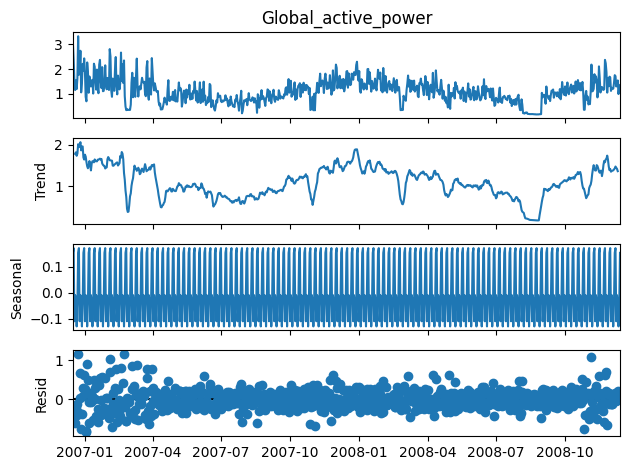

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Global_active_power'], model='additive', period=7)
decomposition.plot()
plt.show()

In [1]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df['diff'].dropna(), lags=40)
plt.title("ACF Plot")
plt.show()

NameError: name 'plt' is not defined

<Figure size 1000x400 with 0 Axes>

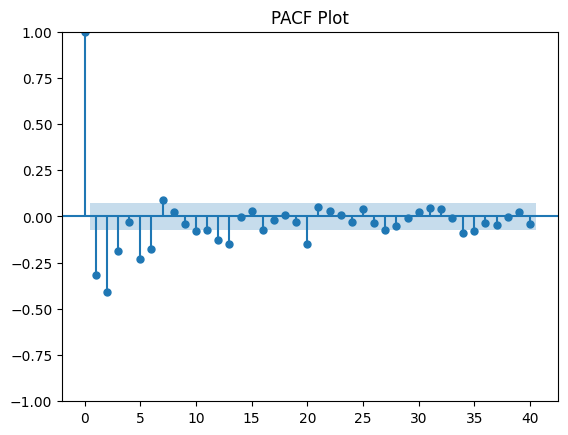

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,4))
plot_pacf(df['diff'].dropna(), lags=40)
plt.title("PACF Plot")
plt.show()

In [ ]:
split = int(len(df) * 0.8)

train = df['diff'][:split]
test = df['diff'][split:]

#ARIMA MODEL

In [ ]:
model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()

pred_arima = model_arima_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


#SARIMA MODEL

In [ ]:
model_sarima= SARIMAX(train,
                order=(2,1,2),
                seasonal_order=(1,1,1,7))

model_sarima_fit = model_sarima.fit()

pred_sarima = model_sarima_fit.forecast(len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 0.5065527414046818
SARIMA RMSE: 0.5058939674459614


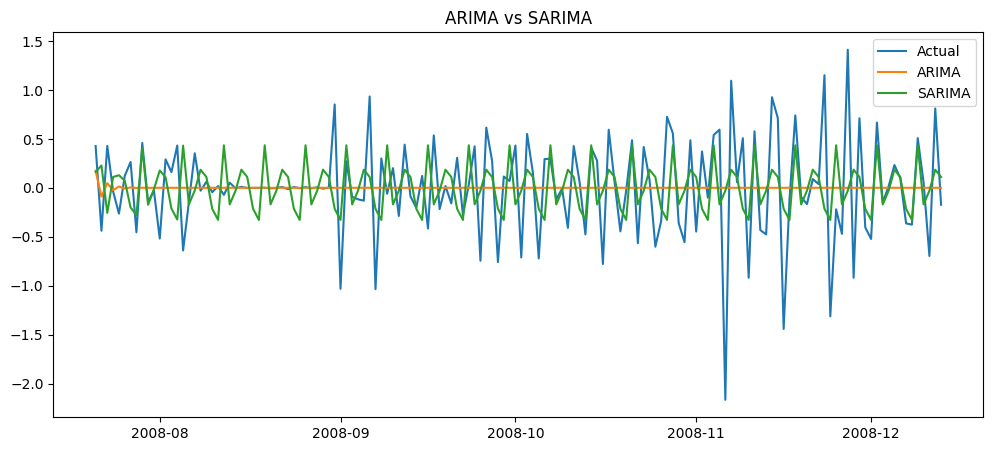

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test, label='Actual')
plt.plot(pred_arima, label='ARIMA')
plt.plot(pred_sarima, label='SARIMA')
plt.legend()
plt.title("ARIMA vs SARIMA")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred_sarima))
print("Final SARIMA RMSE:", rmse)

Final SARIMA RMSE: 0.5058939674459614


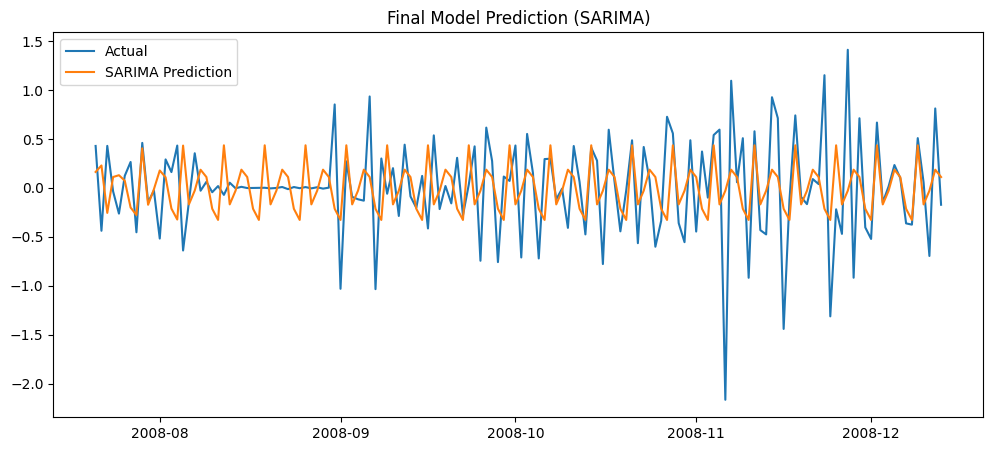

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test, label='Actual')
plt.plot(pred_sarima, label='SARIMA Prediction')

plt.legend()
plt.title("Final Model Prediction (SARIMA)")
plt.show()

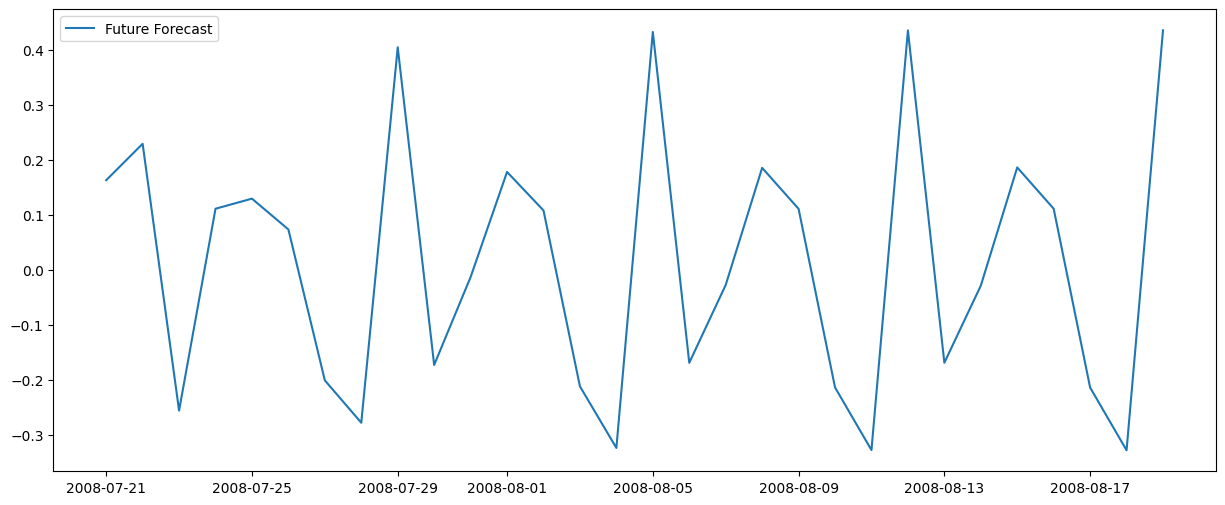

In [ ]:
future_pred = model_sarima_fit.forecast(steps=30)

plt.figure(figsize=(15,6))
plt.plot(future_pred, label='Future Forecast')
plt.legend()
plt.show()

👉 About ARIMA:
“ARIMA model produced nearly constant predictions, indicating its inability to capture seasonal variations in the data.”

👉 About SARIMA:
“SARIMA model performed better as it captured both trend and seasonal patterns, resulting in predictions closer to actual values.”